# Practical 4: Image Enhancement in Frequency Domain

## Part 4A: Performing DFT and IDFT

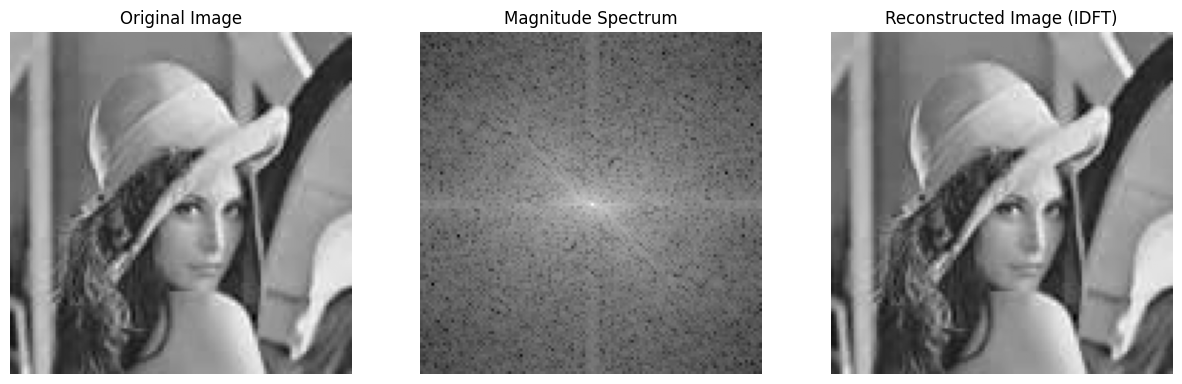

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
IMG_PATH = "C:/Users/shiva/Downloads/lina.jpeg"
image = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Please ensure 'lena.jpg' is in the current directory.")
    exit()

# Compute the Discrete Fourier Transform (DFT)
dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft) # Shift the zero-frequency component to the center

# Compute the magnitude spectrum
magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
magnitude_spectrum = 20 * np.log(magnitude + 1) # Add 1 to avoid log(0)

# Inverse Discrete Fourier Transform (IDFT)
dft_ishift = np.fft.ifftshift(dft_shift) # Shift back
idft = cv2.idft(dft_ishift)

# Reconstruct the image (using magnitude, ensuring real values)
reconstructed_image = cv2.magnitude(idft[:, :, 0], idft[:, :, 1])

# Normalize and convert to uint8
reconstructed_image = cv2.normalize(reconstructed_image, None, 0, 255, cv2.NORM_MINMAX)
reconstructed_image = reconstructed_image.astype(np.uint8)

# Resize the reconstructed image to match the original image's dimensions
reconstructed_image = cv2.resize(reconstructed_image, (image.shape[1], image.shape[0]))

# Display the images using subplots with controlled aspect ratio
plt.figure(figsize=(15, 5)) # Adjusted figure size to accommodate 3 subplots

plt.subplot(1, 3, 1) # 1 row, 3 columns, first subplot
plt.imshow(image, cmap='gray', aspect='equal')
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, second subplot
plt.imshow(magnitude_spectrum, cmap='gray', aspect='equal') # Displaying magnitude spectrum
plt.title('Magnitude Spectrum'), plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, third subplot
plt.imshow(reconstructed_image, cmap='gray', aspect='equal')
plt.title('Reconstructed Image (IDFT)'), plt.axis('off')

plt.show()

# Save the results
cv2.imwrite('magnitude_spectrum.jpg', magnitude_spectrum)
cv2.imwrite('reconstructed_image.jpg', reconstructed_image)

## Part 4B: Ideal, Butterworth and Gaussian LPFs

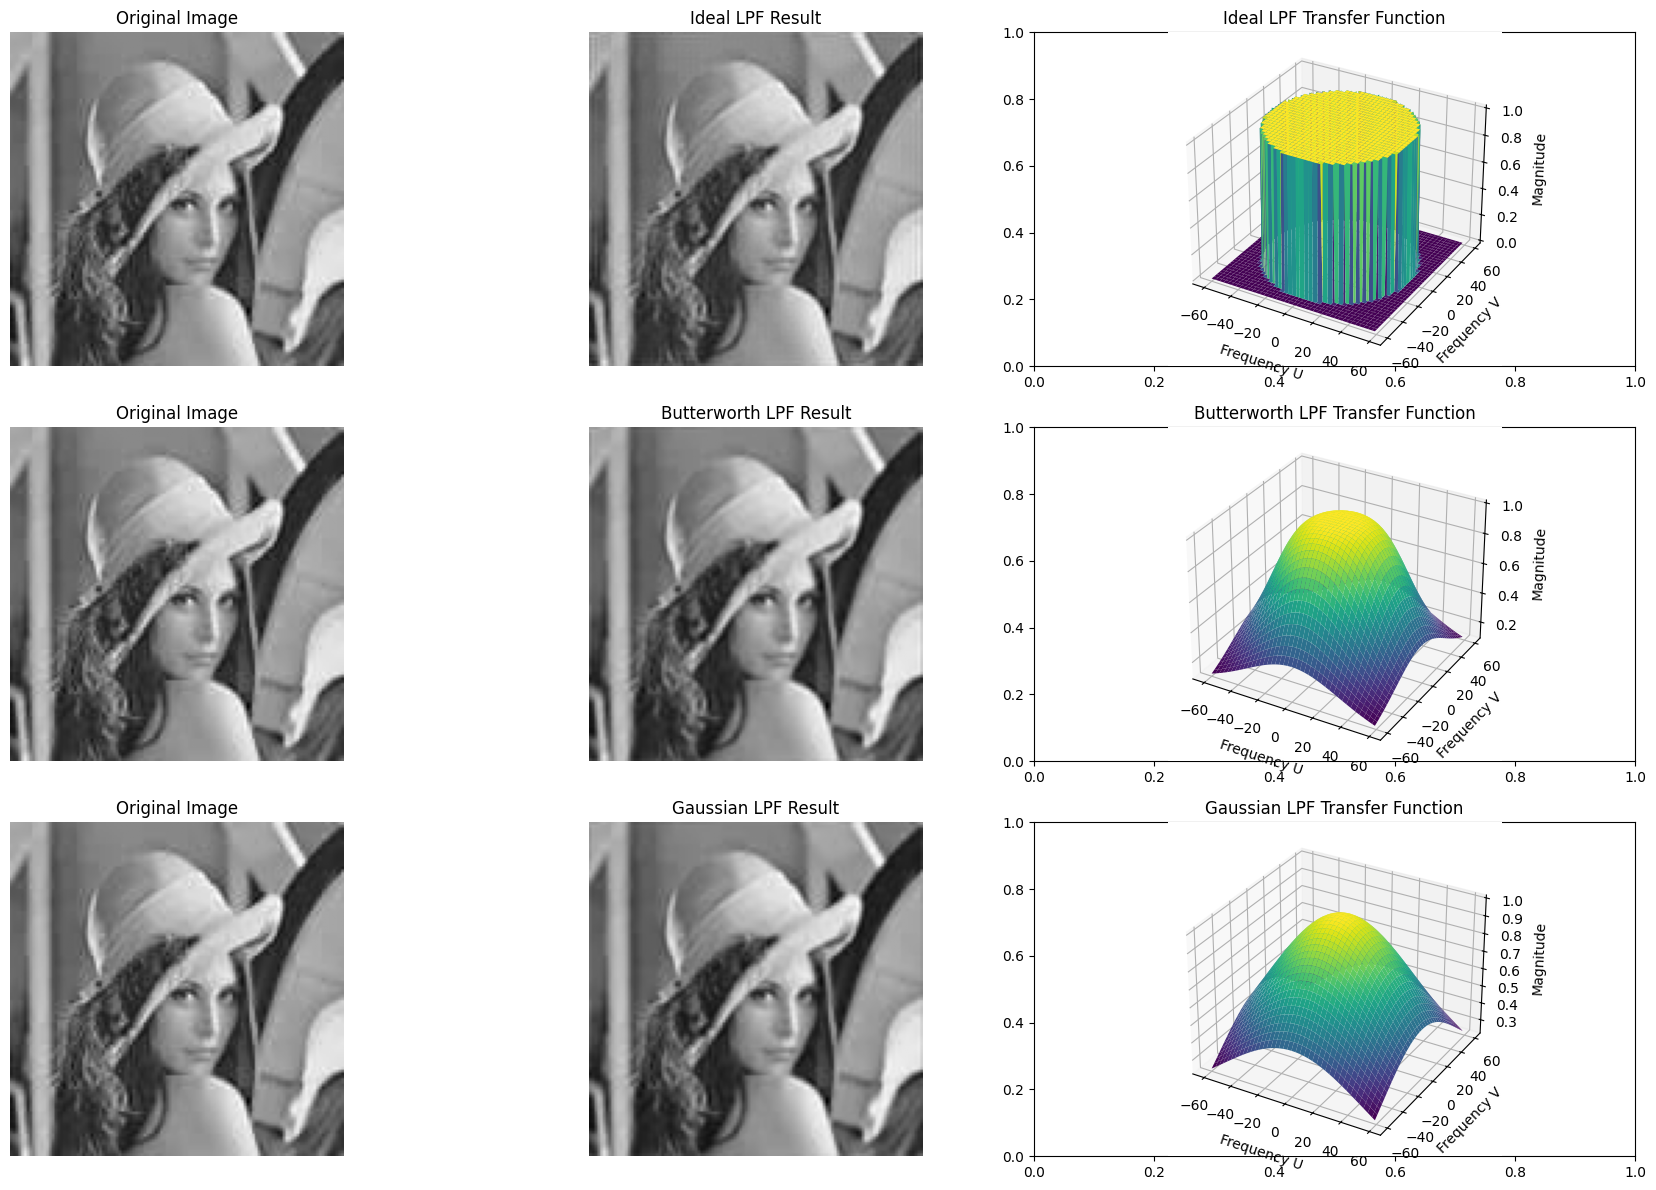

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the image in grayscale
IMG_PATH = "C:/Users/shiva/Downloads/lina.jpeg"
image = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Please ensure 'lena.jpg' is in the current directory.")
    exit()

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2 # Center of the frequency domain

# Frequency grid
u = np.arange(-ccol, ccol)
v = np.arange(-crow, crow)
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# Filter Functions
def ideal_lpf(D, cutoff):
    H = np.zeros_like(D)
    H[D <= cutoff] = 1
    return H

def butterworth_lpf(D, cutoff, order):
    H = 1 / (1 + (D / cutoff)**(2 * order))
    return H

def gaussian_lpf(D, cutoff):
    H = np.exp(-(D**2) / (2 * (cutoff**2)))
    return H

# Apply filters and visualize
def apply_filter(image, filter_function):
    dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shifted = np.fft.fftshift(dft)
    filter_mask = filter_function(D)
    filtered = dft_shifted * filter_mask[:, :, np.newaxis]
    dft_ishifted = np.fft.ifftshift(filtered)
    idft = cv2.idft(dft_ishifted)
    result = cv2.magnitude(idft[:, :, 0], idft[:, :, 1])
    return filter_mask, cv2.normalize(result, None, 0, 255, cv2.NORM_MINMAX)

# Filter parameters
cutoff = 50
order = 2

# Apply the three filters
ideal_mask, ideal_result = apply_filter(image, lambda D: ideal_lpf(D, cutoff))
butter_mask, butter_result = apply_filter(image, lambda D: butterworth_lpf(D, cutoff, order))
gaussian_mask, gaussian_result = apply_filter(image, lambda D: gaussian_lpf(D, cutoff))

# Subplots for each filter
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Plot for Ideal Low Pass Filter
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.uint8(ideal_result), cmap='gray')
axes[0, 1].set_title('Ideal LPF Result')
axes[0, 1].axis('off')

ax = fig.add_subplot(331 + 2, projection='3d')
ax.plot_surface(U, V, ideal_mask, cmap='viridis')
ax.set_title('Ideal LPF Transfer Function')
ax.set_xlabel('Frequency U')
ax.set_ylabel('Frequency V')
ax.set_zlabel('Magnitude')

# Plot for Butterworth Low Pass Filter
axes[1, 0].imshow(image, cmap='gray')
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.uint8(butter_result), cmap='gray')
axes[1, 1].set_title('Butterworth LPF Result')
axes[1, 1].axis('off')

ax = fig.add_subplot(331 + 5, projection='3d')
ax.plot_surface(U, V, butter_mask, cmap='viridis')
ax.set_title('Butterworth LPF Transfer Function')
ax.set_xlabel('Frequency U')
ax.set_ylabel('Frequency V')
ax.set_zlabel('Magnitude')

# Plot for Gaussian Low Pass Filter
axes[2, 0].imshow(image, cmap='gray')
axes[2, 0].set_title('Original Image')
axes[2, 0].axis('off')

axes[2, 1].imshow(np.uint8(gaussian_result), cmap='gray')
axes[2, 1].set_title('Gaussian LPF Result')
axes[2, 1].axis('off')

ax = fig.add_subplot(331 + 8, projection='3d')
ax.plot_surface(U, V, gaussian_mask, cmap='viridis')
ax.set_title('Gaussian LPF Transfer Function')
ax.set_xlabel('Frequency U')
ax.set_ylabel('Frequency V')
ax.set_zlabel('Magnitude')

plt.tight_layout()
plt.show()

## Part 4B: Ideal, Butterworth and Gaussian HPFs

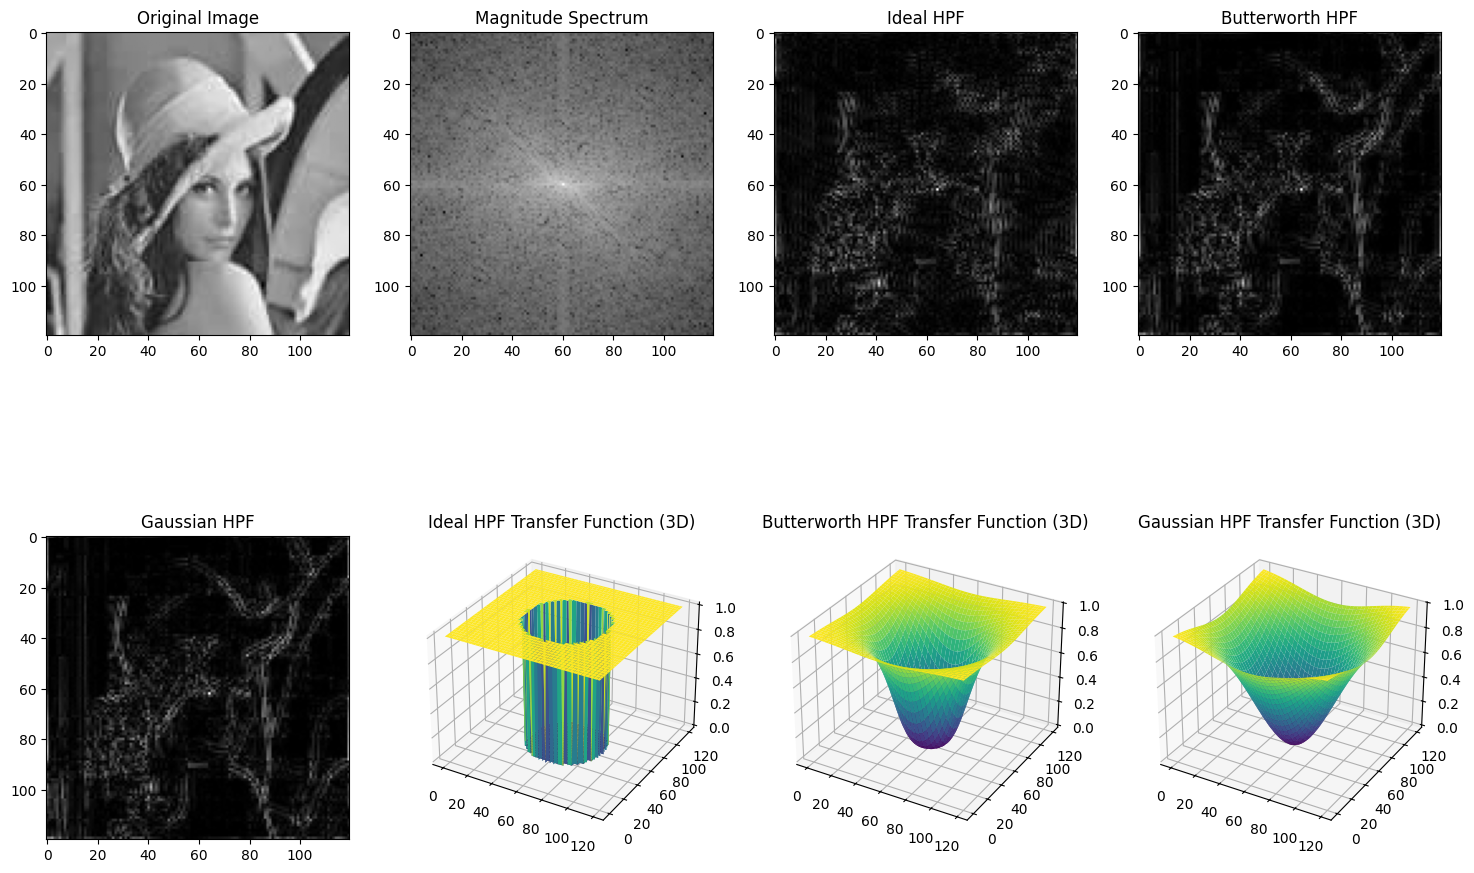

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def ideal_highpass_filter(shape, cutoff_frequency):
    """Creates an ideal high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), cutoff_frequency, 0, -1)
    return mask

def butterworth_highpass_filter(shape, cutoff_frequency, order=2):
    """Creates a Butterworth high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            dist = np.sqrt((i - crow)**2 + (j - ccol)**2)
            if dist == 0:
                mask[i, j] = 0 # Prevent division by zero error
            else:
                mask[i, j] = 1 / (1 + (cutoff_frequency / dist)**(2 * order))
    return mask

def gaussian_highpass_filter(shape, cutoff_frequency):
    """Creates a Gaussian high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            dist = np.sqrt((i - crow)**2 + (j - ccol)**2)
            mask[i, j] = 1 - np.exp(-(dist**2) / (2 * (cutoff_frequency**2)))
    return mask

# Load the image in grayscale
IMG_PATH = "C:/Users/shiva/Downloads/lina.jpeg"
image = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Please ensure 'lena.jpg' is in the current directory.")
    exit()

# Compute the DFT
dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Compute the magnitude spectrum
magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
magnitude_spectrum = 20 * np.log(magnitude + 1) # Add 1 to avoid log(0)

# Create the filters
cutoff_frequency = 30 # Adjust as needed
ideal_mask = ideal_highpass_filter(image.shape, cutoff_frequency)
butterworth_mask = butterworth_highpass_filter(image.shape, cutoff_frequency)
gaussian_mask = gaussian_highpass_filter(image.shape, cutoff_frequency)

# Apply the filters
filtered_ideal = dft_shift * ideal_mask[:, :, np.newaxis]
filtered_butterworth = dft_shift * butterworth_mask[:, :, np.newaxis]
filtered_gaussian = dft_shift * gaussian_mask[:, :, np.newaxis]

# Compute the IDFT
ideal_ishift = np.fft.ifftshift(filtered_ideal)
butterworth_ishift = np.fft.ifftshift(filtered_butterworth)
gaussian_ishift = np.fft.ifftshift(filtered_gaussian)

ideal_back = cv2.idft(ideal_ishift)
butterworth_back = cv2.idft(butterworth_ishift)
gaussian_back = cv2.idft(gaussian_ishift)

# Reconstruct the images (using magnitude)
ideal_image = cv2.magnitude(ideal_back[:, :, 0], ideal_back[:, :, 1])
butterworth_image = cv2.magnitude(butterworth_back[:, :, 0], butterworth_back[:, :, 1])
gaussian_image = cv2.magnitude(gaussian_back[:, :, 0], gaussian_back[:, :, 1])

# Normalize for display
ideal_image = cv2.normalize(ideal_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
butterworth_image = cv2.normalize(butterworth_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gaussian_image = cv2.normalize(gaussian_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Display the results
plt.figure(figsize=(18, 12)) # Adjusted figure size for more subplots

# Original Image and Magnitude Spectrum
plt.subplot(2, 4, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
plt.subplot(2, 4, 2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Magnitude Spectrum')

# Filtered Images
plt.subplot(2, 4, 3), plt.imshow(ideal_image, cmap='gray'), plt.title('Ideal HPF')
plt.subplot(2, 4, 4), plt.imshow(butterworth_image, cmap='gray'), plt.title('Butterworth HPF')
plt.subplot(2, 4, 5), plt.imshow(gaussian_image, cmap='gray'), plt.title('Gaussian HPF')

# Perspective Plots of Transfer Functions
X, Y = np.meshgrid(np.arange(ideal_mask.shape[1]), np.arange(ideal_mask.shape[0]))

ax1 = plt.subplot(2, 4, 6, projection='3d')
ax1.plot_surface(X, Y, ideal_mask, cmap='viridis')
ax1.set_title('Ideal HPF Transfer Function (3D)')

ax2 = plt.subplot(2, 4, 7, projection='3d')
ax2.plot_surface(X, Y, butterworth_mask, cmap='viridis')
ax2.set_title('Butterworth HPF Transfer Function (3D)')

ax3 = plt.subplot(2, 4, 8, projection='3d')
ax3.plot_surface(X, Y, gaussian_mask, cmap='viridis')
ax3.set_title('Gaussian HPF Transfer Function (3D)')

plt.show()